In [4]:
!unzip "/content/dataset/DS-S-WE-T-B116 & DS-S-WE-T-B123 - Final Project/brc.zip" -d "/content/dataset/extracted_brc/"

Streaming output truncated to the last 5000 lines.
 extracting: /content/dataset/extracted_brc/train/rotten/musa-acuminata-rotten-8866be06-2653-11ec-9d14-d8c4975e38aa_jpg.rf.d8cb757ca745d87c0ca4b4f098919774.jpg  
 extracting: /content/dataset/extracted_brc/train/rotten/musa-acuminata-rotten-886d4971-2653-11ec-b3fd-d8c4975e38aa_jpg.rf.b53483ace776353acb80750c43830b88.jpg  
 extracting: /content/dataset/extracted_brc/train/rotten/musa-acuminata-rotten-886d4971-2653-11ec-b3fd-d8c4975e38aa_jpg.rf.c4148a82de9a57d6e83bc19a6f6b51aa.jpg  
 extracting: /content/dataset/extracted_brc/train/rotten/musa-acuminata-rotten-886d4971-2653-11ec-b3fd-d8c4975e38aa_jpg.rf.f5eaa276d840f235f7a314c05249e4b2.jpg  
 extracting: /content/dataset/extracted_brc/train/rotten/musa-acuminata-rotten-886f8f7c-2653-11ec-8f57-d8c4975e38aa_jpg.rf.28fb58807c2b04aa2d7f81b28a692add.jpg  
 extracting: /content/dataset/extracted_brc/train/rotten/musa-acuminata-rotten-886f8f7c-2653-11ec-8f57-d8c4975e38aa_jpg.rf.2bd3da96d1f1158e

In [5]:
########################################################
# Advanced Banana Ripeness & Quality Detection Project
# Notebook 01 : Data Preparation & Dataset Validation
########################################################

# Purpose:
# 1. Verify dataset structure
# 2. Check class distribution
# 3. Detect corrupted images
# 4. Detect duplicates
# 5. Visualize samples
# 6. Create augmentation pipeline
# 7. Prepare TensorFlow datasets

print("Data Preparation Notebook Started")

Data Preparation Notebook Started


# **01 Data Preparation**

In [7]:
import os
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator


# 1. DEFINE DIRECTORY PATHS
###########
# Pointing directly to the folder
base_dir = '/content/dataset/extracted_brc'

train_dir = os.path.join(base_dir, 'train')
val_dir = os.path.join(base_dir, 'valid')
test_dir = os.path.join(base_dir, 'test')

# Verify that the directories exist
print("Directory verification:")
print(f"Train path exists: {os.path.exists(train_dir)}")
print(f"Valid path exists: {os.path.exists(val_dir)}")
print(f"Test path exists:  {os.path.exists(test_dir)}")

Directory verification:
Train path exists: True
Valid path exists: True
Test path exists:  True



Loading Training Data...
Found 11793 images belonging to 4 classes.

Loading Validation Data...
Found 1123 images belonging to 4 classes.

Loading Testing Data...
Found 562 images belonging to 4 classes.

Detected Classes: ['overripe', 'ripe', 'rotten', 'unripe']


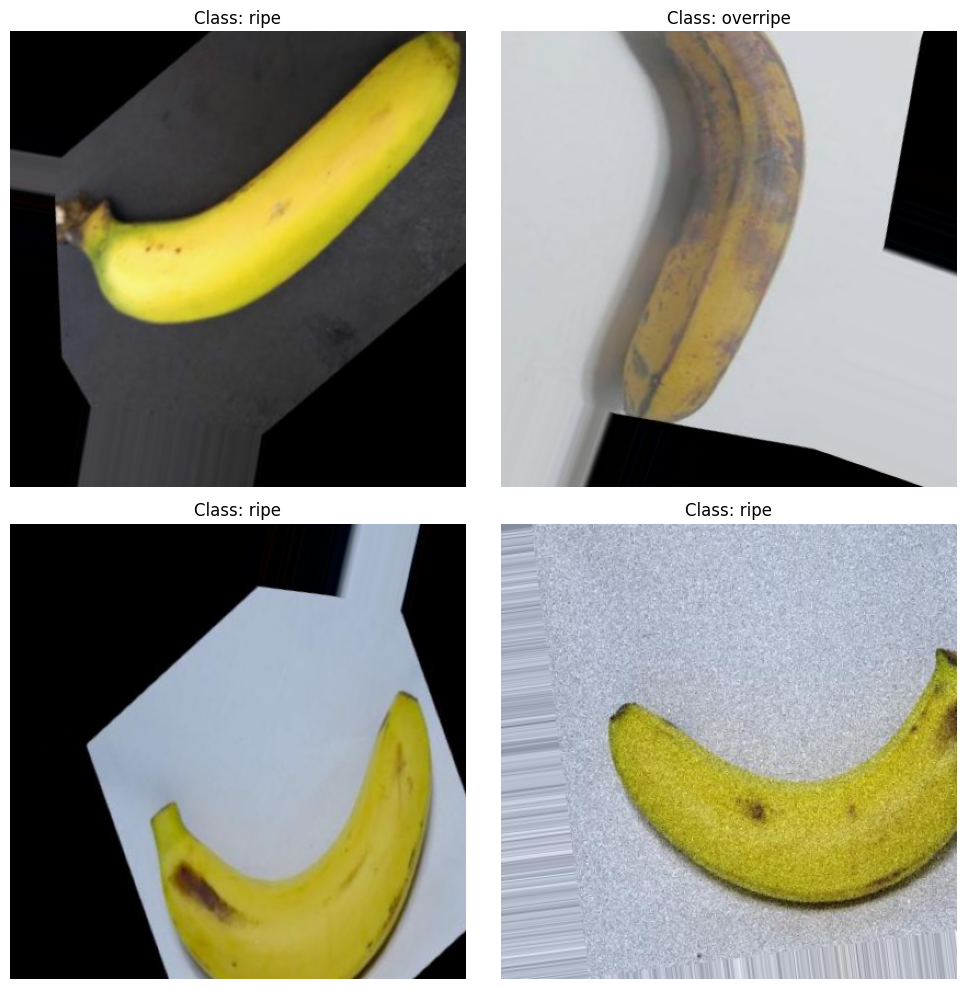

In [8]:

# 2. SET IMAGE PARAMETERS
###############################


# The project requires a 416x416 input size
IMG_HEIGHT = 416
IMG_WIDTH = 416
BATCH_SIZE = 32

##############################
# 3. CONFIGURE DATA GENERATORS (With Augmentation)
##############################

# Training Generator: We apply augmentation here to prevent overfitting.
# to train model using slightly modified versions of the bananas every epoch.
train_datagen = ImageDataGenerator(
    rescale=1./255,           # Normalize pixel values to be between 0 and 1
    rotation_range=20,        # Randomly rotate images
    width_shift_range=0.2,    # Randomly shift images horizontally
    height_shift_range=0.2,   # Randomly shift images vertically
    horizontal_flip=True,     # Randomly flip images left-to-right
    fill_mode='nearest'       # Fill in new pixels created by shifts/rotations
)

# Validation & Test Generator: NO AUGMENTATION.
# We only normalize the pixels. We need these images to represent real, unedited photos.
val_test_datagen = ImageDataGenerator(rescale=1./255)


#####################################
# 4. LOAD THE DATA FROM DIRECTORIES
#####################################

print("\nLoading Training Data...")
train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical' # Used because we have 4 distinct classes
)

print("\nLoading Validation Data...")
val_data = val_test_datagen.flow_from_directory(
    val_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False # We do not shuffle validation data so we can accurately track metrics
)

print("\nLoading Testing Data...")
test_data = val_test_datagen.flow_from_directory(
    test_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False # Never shuffle test data, or your evaluation metrics will misalign
)


######################################
# 5. VISUALIZATION & SANITY CHECK
######################################


# extracting the automatically detected class names
class_names = list(train_data.class_indices.keys())
print(f"\nDetected Classes: {class_names}")

# Fetching a batch of images and labels to ensure everything loaded correctly
images, labels = next(train_data)

# Plotting the first 4 images of the batch
plt.figure(figsize=(10, 10))
for i in range(4):
    plt.subplot(2, 2, i + 1)
    # Using generator to normalize pixels to 0-1, which matplotlib handles perfectly
    plt.imshow(images[i])

    # Find the index of the '1' in the one-hot encoded label to get the class name
    label_index = list(labels[i]).index(1.0)
    plt.title(f"Class: {class_names[label_index]}")
    plt.axis('off')

plt.tight_layout()
plt.show()